## Importing Files

In [2]:
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))
from utils import process_electricity_data, process_weather_data

data_dir = Path("..") / "data"
file_elec_consum = data_dir / 'Electricity consumption.csv'
file_weather = data_dir / 'Weather data.csv'
load = pd.read_csv(file_elec_consum)
weather = pd.read_csv(file_weather)

## Understanding the building electricity load

### **Target feature exploration**

In [4]:
load.head()

,date_time,Electricity consumption (kW)
0,1/1/2018 0:15,430
1,1/1/2018 0:30,420
2,1/1/2018 0:45,440
3,1/1/2018 1:00,420
4,1/1/2018 1:15,420


In [5]:
load.info()

<class 'pandas.DataFrame'>
RangeIndex: 40415 entries, 0 to 40414
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   date_time                     40415 non-null  str  
 1   Electricity consumption (kW)  40415 non-null  int64
dtypes: int64(1), str(1)
memory usage: 631.6 KB


In [6]:
load.describe()

,Electricity consumption (kW)
count,40415.000000
mean,388.937276
std,142.314784
min,0.000000
25%,260.000000
50%,330.000000
75%,520.000000
max,870.000000


Zero values are observed in the electricity consumption data.
Unlike weather variables, a zero electricity demand is physically possible and may correspond to building shutdowns, maintenance periods, or exceptional operating conditions.

As these events are exceptionnal behavior, zero values were treated as outliers

In [9]:
load["date_time"] = pd.to_datetime(load["date_time"])
load = load.set_index("date_time").sort_index()

Let's check where 0 values are located 

In [8]:
load[load["Electricity consumption (kW)"] == 0]

,date_time,Electricity consumption (kW)
7053,3/15/2018 11:30,0
7054,3/15/2018 11:45,0
7055,3/15/2018 12:00,0
7058,3/15/2018 12:45,0
7061,3/15/2018 13:30,0
7064,3/15/2018 14:15,0
7738,3/22/2018 14:45,0


As excepected, definitly, It stands for batiment's shutdown

<Axes: xlabel='date_time'>

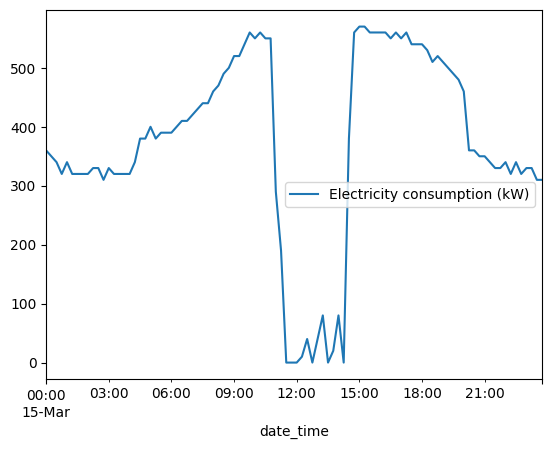

In [ ]:
load.loc['2018-03-15'].plot()

To enable a good model perfomances, we will impute these outiliers later.

### **a. What is the electricity consumption (kWh) and the peak demand (kW) of the building per month in 2018?**

In [10]:
load_data_2018 = load.loc[load.index.year == 2018]
load_data_2018["energy_kWh"] = load_data_2018["Electricity consumption (kW)"] * 0.25

In [11]:
monthly = load_data_2018.resample("ME").agg(
    monthly_energy_kWh=("energy_kWh", "sum"),
    peak_demand_kW=("Electricity consumption (kW)", "max")
)

In [13]:
monthly

,monthly_energy_kWh,peak_demand_kW
date_time,,
2018-01-31,324327.5,630
2018-02-28,270845.0,720
2018-03-31,285320.0,600
2018-04-30,264882.5,640
2018-05-31,295582.5,790
2018-06-30,294685.0,790
2018-07-31,314470.0,840
2018-08-31,320292.5,840
2018-09-30,280152.5,870


Text(0.5, 1.0, 'Electricity consumption (kWh) and the peak demand (kW) per month in 2018')

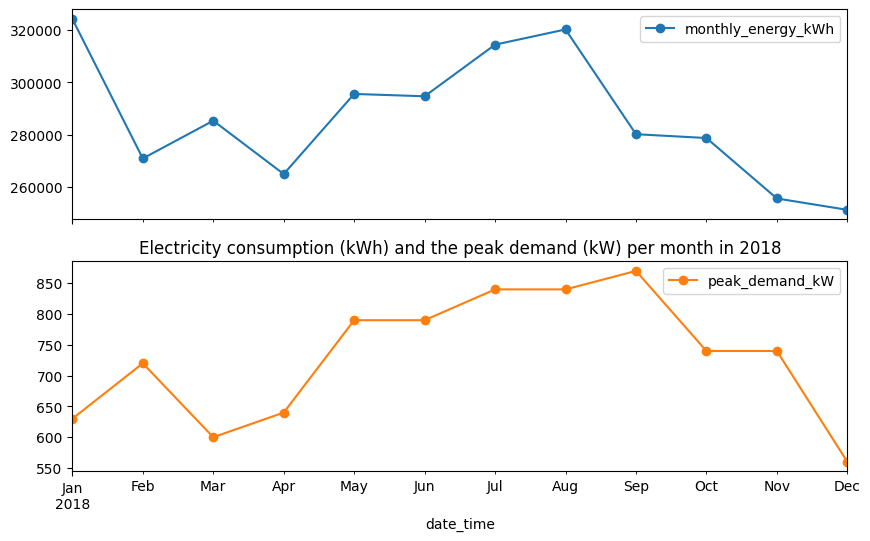

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly.plot(subplots=True, figsize=(10,6), marker='o')
plt.title("Electricity consumption (kWh) and the peak demand (kW) per month in 2018")

Electricity consumption is highest in summer (July–August) and lowest in winter (November–December). Peak demand follows a similar pattern, reaching its maximum in September, indicating higher load stress during late summer.
This difference highlights the distinction between energy usage and instantaneous demand.

### **b. How does electricity demand vary?**

#### i. Hourly profile

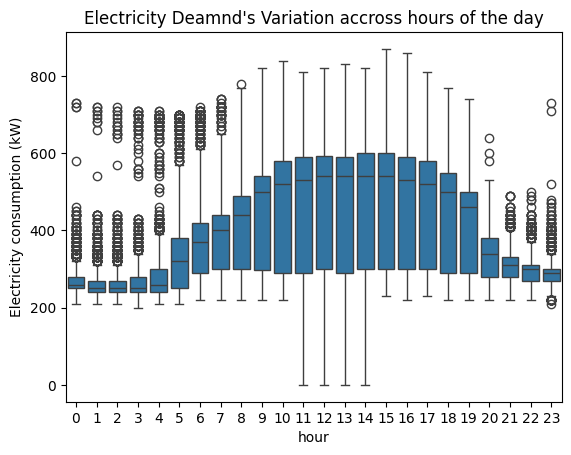

In [14]:
load_data = load
load_data["hour"] = load_data.index.hour
sns.boxplot(data = load_data, x = 'hour' , y = 'Electricity consumption (kW)')
plt.title("Electricity Demand's Variation accross hours of the day")
plt.show()

Electricity demand is lowest during late night and early morning (00:00–05:00 a.m), rises steadily from early morning (06:00–09:00 a.m), peaks around midday to mid-afternoon (11:00–16:00 p.m), and then declines gradually in the evening, returning to lower levels late at night.

This analysis highlights the typical daily load profile and the presence of base load and peak demand hours.

#### Futhermore

In [4]:
import sys
sys.path.insert(0, str(Path.cwd().parent))
from utils.profiling_comsumption import ElectricityProfileAnalyzer

ModuleNotFoundError: No module named 'utils.profiling_comsumption.electricity_profile_analyser'

In [ ]:

analyzer = ElectricityProfileAnalyzer(
        resolution='h',
        max_clusters=10
    )
    
daily_profiles, labels, centroids = analyzer.analyze(
        load,
        n_clusters=4, 
        method='kmeans',
        year=None 
    )

#### ii. Day of week analysis

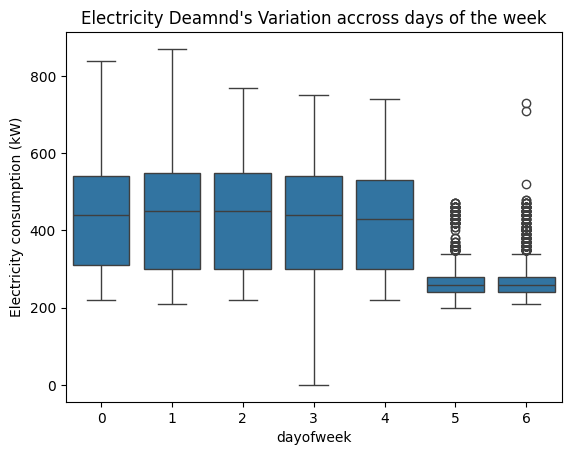

In [15]:
load_data["dayofweek"] = load_data.index.dayofweek
sns.boxplot(data = load_data, x = 'dayofweek' , y = 'Electricity consumption (kW)')
plt.title("Electricity Demand's Variation accross days of the week")
plt.show()

Electricity demand is higher and more variable on weekdays (Monday–Friday), with similar median levels, and significantly lower on weekends (Saturday–Sunday), where demand is more stable and consistently reduced.

Suggesting a basic consumption due to HVAC

#### iii. Seasonal analysis

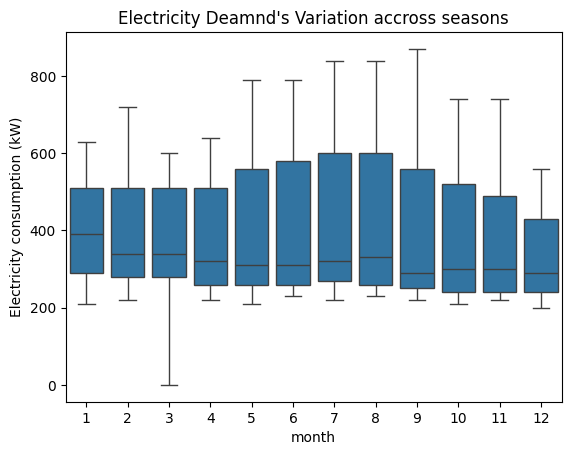

In [16]:
load_data["month"] = load_data.index.month
sns.boxplot(data = load_data, x = 'month' , y = 'Electricity consumption (kW)')
plt.title("Electricity Demand's Variation accross seasons")
plt.show()

    Spring (March–May) : Lowest demand period overall
    Summer (June–August) : Peak demand season
    Autumn (September–November) : Declining demand transitioning from summer peaks
    Winter (December–February) : Moderately elevated demand compared to spring

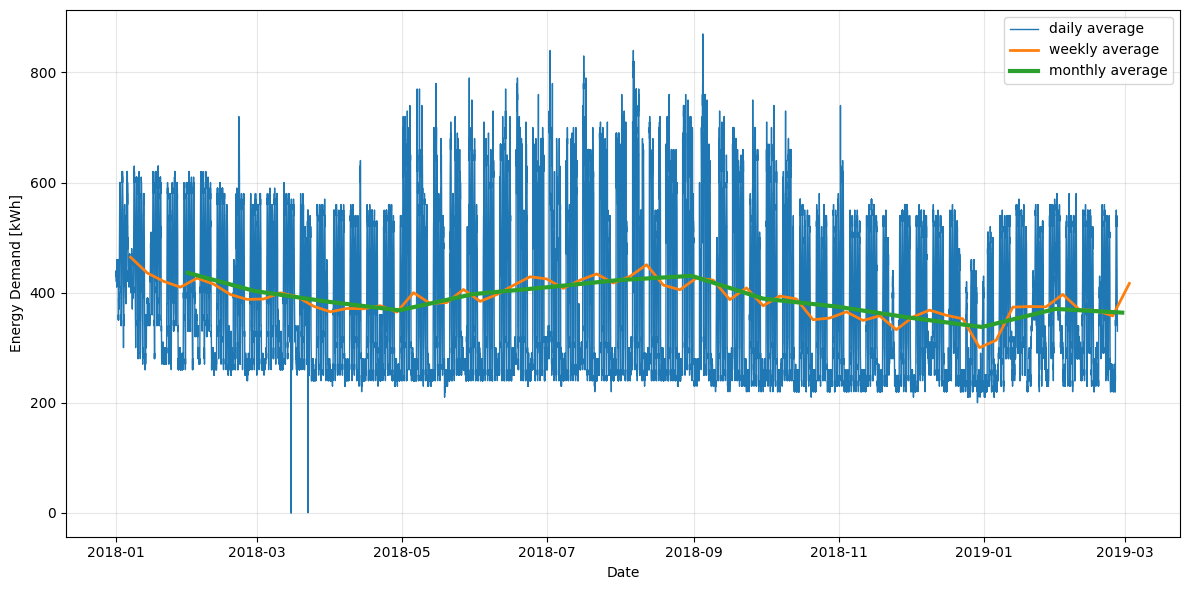

In [18]:
daily_avg = load_data["Electricity consumption (kW)"]
weekly_avg = load_data["Electricity consumption (kW)"].resample("W").mean()
monthly_avg = load_data["Electricity consumption (kW)"].resample("ME").mean()

plt.figure(figsize=(12,6))

plt.plot(daily_avg, label="daily average", linewidth=1)
plt.plot(weekly_avg, label="weekly average", linewidth=2)
plt.plot(monthly_avg, label="monthly average", linewidth=3)

plt.xlabel("Date")
plt.ylabel("Energy Demand [kWh]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Daily demand is highly volatile throughout, with swings regularly spanning 200–870 kWh, though weekly averages smooth this to a consistent seasonal signal. A notable anomaly appears in March 2018, where demand briefly dropped near zero, likely indicating a data gap or outage event.

### c. Relationship with weather variables

In [19]:
weather["date_time"] = pd.to_datetime(weather["date_time"])
weather = weather.set_index("date_time").sort_index()
weather_15min = weather.resample("15min").ffill()
data = load.join(weather_15min, how="inner")

#### 2.3.1 Load vs temperature

Text(0, 0.5, 'Electricity consumption (kW)')

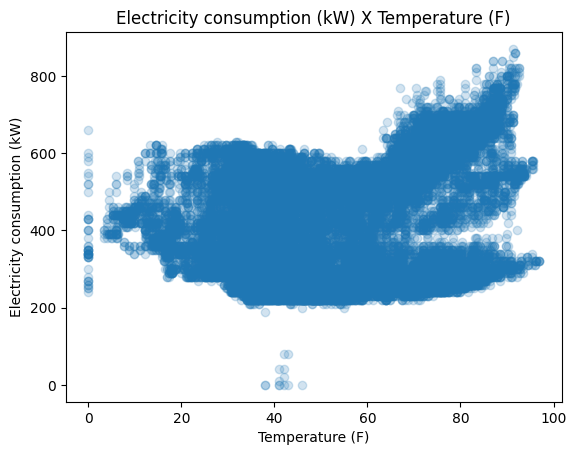

In [21]:
plt.scatter(
    data["Temperature (F)"],
    data["Electricity consumption (kW)"],
    alpha=0.2
)
plt.title("Electricity consumption (kW) X Temperature (F)")
plt.xlabel("Temperature (F)")
plt.ylabel("Electricity consumption (kW)")

The scatter plot of electricity demand versus outdoor temperature suggests the existence of a comfort temperature (typically ~55–65°F) around which HVAC-related load is minimal.
Below this reference temperature, electricity consumption increases due to heating demand, while above it, cooling demand dominates.
This behavior indicates a non-linear relationship between electricity demand and temperature, which can be effectively modeled using a non-linear model.

Text(0, 0.5, 'Electricity consumption (kW)')

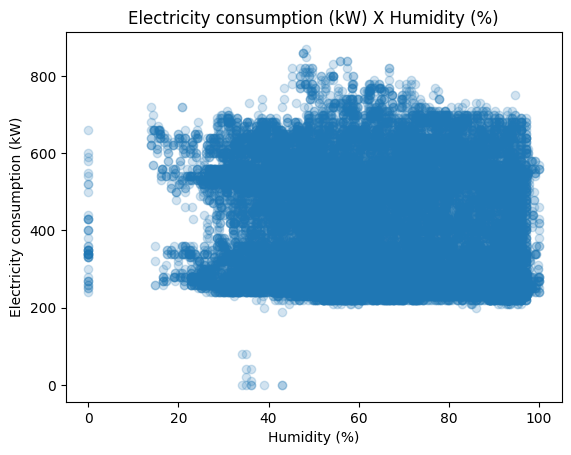

In [22]:
plt.scatter(
    data["Humidity (%)"],
    data["Electricity consumption (kW)"],
    alpha=0.2
)
plt.title("Electricity consumption (kW) X Humidity (%)")
plt.xlabel("Humidity (%)")
plt.ylabel("Electricity consumption (kW)")

Large vertical dispersion for almost all humidity values. For the same humidity value, consumption varies significantly at constant humidity

Humidity alone cannot explain the variations in consumption